In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge,Lasso
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import root_mean_squared_error


In [2]:
DF = pd.read_excel("/Users/arjun/Desktop/FC1_Ageing_part1.xlsx")



In [4]:
DF = DF.sort_values(by="Time (h)")
DF = DF.reset_index(drop=True)
DF.head(25)
DF["Utot (V)"].describe()


count    65535.000000
mean         3.309475
std          0.027311
min          3.253000
25%          3.285000
50%          3.308000
75%          3.335000
max          3.365000
Name: Utot (V), dtype: float64

In [5]:
X = DF.drop(["Utot (V)","U1 (V)","U2 (V)","U3 (V)","U4 (V)","U5 (V)"],axis=1).values
y = DF["Utot (V)"].values
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(np.mean(X),np.std(X))
print(np.mean(X_train_scaled),np.std(X_train_scaled))
print(np.mean(X_test_scaled),np.std(X_test_scaled))


306.70873145210413 510.7211865352068
2.3454480782334436e-11 0.9999999999999841
-0.0005072183381178551 1.0002226781100207


In [6]:
kf = KFold(n_splits=5,shuffle=True,random_state=42)
param_grid = {"alpha":[0.1, 1, 10, 100, 1000]}
ridge = Ridge()
ridge_cv = GridSearchCV(ridge,param_grid,cv=kf)
ridge_cv.fit(X_train_scaled,y_train)
print(ridge_cv.best_params_,ridge_cv.best_score_)

{'alpha': 1} 0.9356701845625915


In [7]:
lasso_params = {"alpha": [0.0001, 0.001, 0.01, 0.1]}
lasso_cv = GridSearchCV(Lasso(), lasso_params, cv=kf)
lasso_cv.fit(X_train_scaled, y_train)
print(f"Lasso Best Alpha: {lasso_cv.best_params_}")

Lasso Best Alpha: {'alpha': 0.0001}


/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65394 (\N{HALFWIDTH KATAKANA LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65392 (\N{HALFWIDTH KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


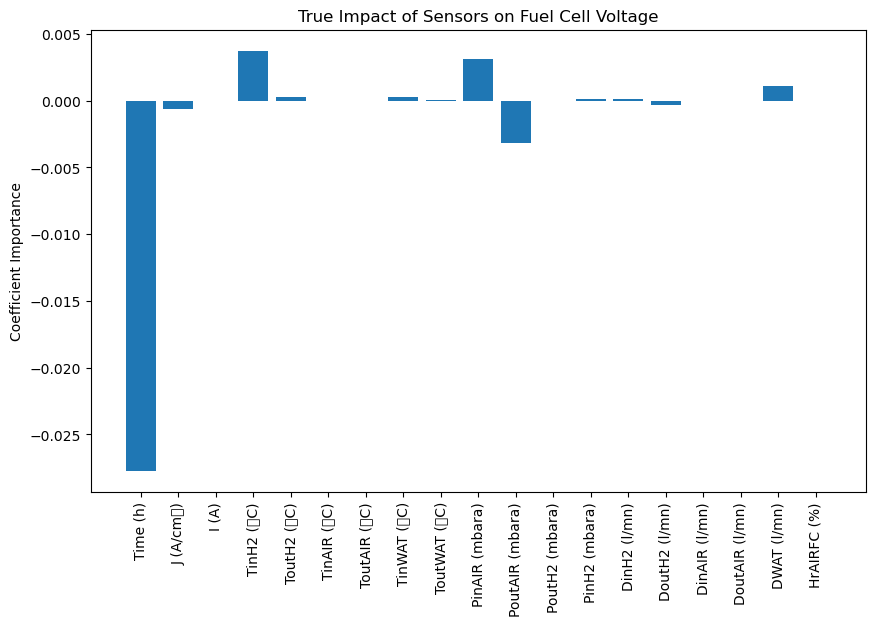

In [8]:
lasso = Lasso(alpha=0.0001)
names = DF.drop(["Utot (V)","U1 (V)","U2 (V)","U3 (V)","U4 (V)","U5 (V)"],axis=1).columns
lasso_coeff = lasso.fit(X_train_scaled,y_train).coef_
plt.figure(figsize=(10, 6))
plt.bar(names, lasso_coeff)
plt.xticks(rotation=90)
plt.ylabel("Coefficient Importance")
plt.title("True Impact of Sensors on Fuel Cell Voltage")
plt.show()

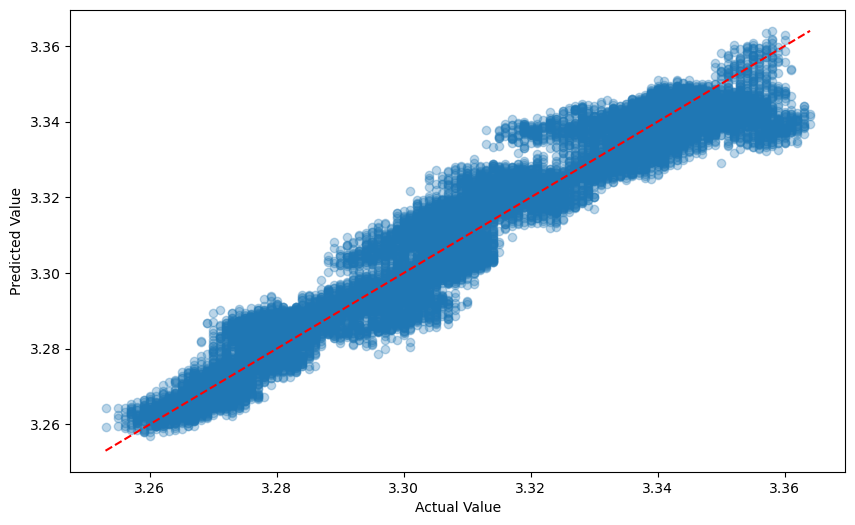

In [12]:
y_pred = ridge_cv.predict(X_test_scaled)
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

In [10]:
root_mean_squared_error(y_test,y_pred)

0.006918953639621567

In [15]:
feature_names = DF.drop(["Utot (V)","U1 (V)","U2 (V)","U3 (V)","U4 (V)","U5 (V)"], axis=1).columns
steady_state_values = DF[feature_names].median().values.reshape(1, -1)
future_df = pd.DataFrame(steady_state_values, columns=feature_names)
future_df['Time (h)'] = 1000.0
future_scaled = scaler.transform(future_df.values) 
predicted_v_1000 = ridge_cv.predict(future_scaled)
print(f"Predicted Voltage at 1000 hours: {predicted_v_1000[0]:.4f} V")

Predicted Voltage at 1000 hours: 3.1691 V
